# Project 1 — Evaluation (Task 3)
This notebook covers **Task 3 (Model Evaluation)**:
- Report **Precision / Recall / mAP@0.5 / mAP@0.5:0.95** on **test** set
- Save **good** and **failed** detections
- Compare **YOLOv8n vs YOLOv8s** (backbone/model size)

In [1]:
pip install ultralytics opencv-python matplotlib scikit-learn pyyaml


Note: you may need to restart the kernel to use updated packages.


In [1]:
import random, numpy as np, torch
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [2]:
import ultralytics, torch, platform
print("Ultralytics:", ultralytics.__version__)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Python:", platform.python_version())


Ultralytics: 8.3.246
Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Python: 3.10.19


In [10]:
from pathlib import Path

DATA_ROOT = Path(r"C:\Users\golla\Downloads\archive\The Welding Defect Dataset\The Welding Defect Dataset")  # <-- change
print("DATA_ROOT exists:", DATA_ROOT.exists())
print("Contents:", [p.name for p in DATA_ROOT.iterdir()])

# Check expected folders
for split in ["train", "valid", "test"]:
    print(split, "images:", (DATA_ROOT/split/"images").exists(),
                "labels:", (DATA_ROOT/split/"labels").exists())

DATA_YAML = DATA_ROOT / "data.yaml"
print("data.yaml exists:", DATA_YAML.exists(), DATA_YAML)


DATA_ROOT exists: True
Contents: ['data.yaml', 'data_fixed.yaml', 'test', 'train', 'valid']
train images: True labels: True
valid images: True labels: True
test images: True labels: True
data.yaml exists: True C:\Users\golla\Downloads\Welding\The Welding Defect Dataset\The Welding Defect Dataset\data.yaml


In [12]:
import yaml

cfg = yaml.safe_load((DATA_ROOT/"data.yaml").read_text())
print("data.yaml content:\n", cfg)

names = cfg.get("names")
if isinstance(names, dict):
    CLASS_NAMES = [names[i] for i in sorted(names)]
else:
    CLASS_NAMES = names

print("CLASS_NAMES:", CLASS_NAMES)
print("Number of classes:", len(CLASS_NAMES))


data.yaml content:
 {'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 3, 'names': ['Bad Weld', 'Good Weld', 'Defect']}
CLASS_NAMES: ['Bad Weld', 'Good Weld', 'Defect']
Number of classes: 3


In [15]:
!pip -q install ultralytics



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import yaml

data = yaml.safe_load((DATA_ROOT/"data.yaml").read_text())

# Force local dataset path
data["path"] = str(DATA_ROOT)

# Ensure split paths are correct (most datasets use these)
data["train"] = "train/images"
data["val"]   = "valid/images"
data["test"]  = "test/images"

# Ensure names exist
data["names"] = CLASS_NAMES
data["nc"] = len(CLASS_NAMES)

(DATA_ROOT/"data_local.yaml").write_text(yaml.safe_dump(data, sort_keys=False))
print(" Wrote:", DATA_ROOT/"data_local.yaml")
print((DATA_ROOT/"data_local.yaml").read_text())


 Wrote: C:\Users\golla\Downloads\Welding\The Welding Defect Dataset\The Welding Defect Dataset\data_local.yaml
train: train/images
val: valid/images
test: test/images
nc: 3
names:
- Bad Weld
- Good Weld
- Defect
path: C:\Users\golla\Downloads\Welding\The Welding Defect Dataset\The Welding Defect
  Dataset



In [21]:
from ultralytics import YOLO

BEST_MODEL = r"C:\Users\golla\Welding Project\runs\detect\train2\weights\best.pt"  # <-- paste your exact path here
model = YOLO(BEST_MODEL)

print(" Model loaded successfully!")


 Model loaded successfully!


##  Load best model + evaluate on TEST

## 1) Evaluate YOLOv8s on TEST

In [1]:
from pathlib import Path
from ultralytics import YOLO

DATA_ROOT = Path(r"C:\Users\golla\Downloads\Welding\The Welding Defect Dataset\The Welding Defect Dataset")

# Your best model location (from training output)
BEST_MODEL = Path("runs") / "weld_yolov8s_640" / "weights" / "best.pt"
print("BEST_MODEL exists:", BEST_MODEL.exists(), BEST_MODEL.resolve())

model = YOLO(str(BEST_MODEL))

metrics = model.val(
    data=str(DATA_ROOT/"data_local.yaml"),
    split="test",
    imgsz=640
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)


BEST_MODEL exists: True C:\Users\golla\Welding Project\runs\weld_yolov8s_640\weights\best.pt
Ultralytics 8.3.246  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.60.3 ms, read: 5.21.3 MB/s, size: 48.4 KB)
val: Scanning C:\Users\golla\Downloads\Welding\The Welding Defect Dataset\The Welding Defect Dataset\test\labels... 74 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 74/74 214.0it/s 0.3s0.1s
val: New cache created: C:\Users\golla\Downloads\Welding\The Welding Defect Dataset\The Welding Defect Dataset\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.0s/it 10.1s.2s5
                   all         74        209      0.631      0.553      0.591      0.333
              Bad Weld         39         67      0.758      0.582      0.723      0.438
         

In [2]:
import random
from pathlib import Path

test_dir = DATA_ROOT/"test"/"images"
test_imgs = []
for ext in ("*.jpg","*.jpeg","*.png"):
    test_imgs += list(test_dir.glob(ext))

random.shuffle(test_imgs)
sample = test_imgs[:25]  # save more so you can pick failures too

model.predict(
    source=[str(p) for p in sample],
    save=True,
    conf=0.25,
    project="pred_samples",
    name="test_preds_yolov8s_640"
)

print("Saved predictions to:", Path("pred_samples/test_preds_yolov8s_640").resolve())



0: 640x640 3 Bad Welds, 23 Defects, 24.3ms
1: 640x640 1 Bad Weld, 2 Good Welds, 24.3ms
2: 640x640 2 Bad Welds, 1 Defect, 24.3ms
3: 640x640 1 Bad Weld, 2 Good Welds, 24.3ms
4: 640x640 3 Bad Welds, 1 Good Weld, 3 Defects, 24.3ms
5: 640x640 1 Good Weld, 24.3ms
6: 640x640 1 Good Weld, 24.3ms
7: 640x640 3 Good Welds, 2 Defects, 24.3ms
8: 640x640 1 Good Weld, 24.3ms
9: 640x640 (no detections), 24.3ms
10: 640x640 1 Good Weld, 24.3ms
11: 640x640 1 Good Weld, 24.3ms
12: 640x640 1 Good Weld, 24.3ms
13: 640x640 1 Bad Weld, 3 Defects, 24.3ms
14: 640x640 1 Good Weld, 24.3ms
15: 640x640 3 Bad Welds, 24.3ms
16: 640x640 1 Bad Weld, 24.3ms
17: 640x640 1 Good Weld, 24.3ms
18: 640x640 2 Good Welds, 1 Defect, 24.3ms
19: 640x640 2 Good Welds, 24.3ms
20: 640x640 1 Bad Weld, 2 Good Welds, 2 Defects, 24.3ms
21: 640x640 2 Bad Welds, 2 Good Welds, 24.3ms
22: 640x640 (no detections), 24.3ms
23: 640x640 1 Bad Weld, 24.3ms
24: 640x640 1 Good Weld, 24.3ms
Speed: 9.1ms preprocess, 24.3ms inference, 2.5ms postproces

## 2) Evaluate YOLOv8n on TEST 

In [3]:
from ultralytics import YOLO

model_n = YOLO("yolov8n.pt")
model_n.train(
    data=str(DATA_ROOT/"data_local.yaml"),
    epochs=50,
    imgsz=640,
    batch=16,
    seed=42,
    project="runs",
    name="weld_yolov8n_640"
)


Ultralytics 8.3.246  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\golla\Downloads\Welding\The Welding Defect Dataset\The Welding Defect Dataset\data_local.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=weld_yolov8n_640, nbs=64, nms=False, ops

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001C0D5C56950>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [4]:
best_n = Path("runs") / "weld_yolov8n_640" / "weights" / "best.pt"
model_n = YOLO(str(best_n))

m_n = model_n.val(data=str(DATA_ROOT/"data_local.yaml"), split="test", imgsz=640)
print("YOLOv8n mAP@0.5:", m_n.box.map50)
print("YOLOv8n mAP@0.5:0.95:", m_n.box.map)


Ultralytics 8.3.246  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.50.2 ms, read: 46.519.6 MB/s, size: 52.2 KB)
val: Scanning C:\Users\golla\Downloads\Welding\The Welding Defect Dataset\The Welding Defect Dataset\test\labels.cache... 74 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 74/74 73.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.6s/it 13.2s1.1s0
                   all         74        209      0.609      0.511      0.567      0.317
              Bad Weld         39         67      0.765      0.536      0.715      0.432
             Good Weld         51         76      0.614       0.65      0.623      0.359
                Defect         31         66      0.447      0.348      0.362      0.159
Speed: 20.2ms preprocess, 12.9ms inference, 0.0ms 

In [5]:
import pandas as pd

results = [
    ["YOLOv8n", 640, 0.609, 0.511, 0.567, 0.317],
    # Add YOLOv8s row after you evaluate it on test (see next section)
    # ["YOLOv8s", 640, P_s, R_s, mAP50_s, mAP5095_s],
]

df = pd.DataFrame(results, columns=["Model", "imgsz", "Precision", "Recall", "mAP@0.5", "mAP@0.5:0.95"])
df



,Model,imgsz,Precision,Recall,mAP@0.5,mAP@0.5:0.95
0,YOLOv8n,640,0.609,0.511,0.567,0.317


In [6]:
from ultralytics import YOLO
from pathlib import Path

DATA_ROOT = Path(r"C:\Users\golla\Downloads\Welding\The Welding Defect Dataset\The Welding Defect Dataset")

best_s = Path("runs") / "weld_yolov8s_640" / "weights" / "best.pt"
print("best_s exists:", best_s.exists(), best_s)

model_s = YOLO(str(best_s))
m_s = model_s.val(data=str(DATA_ROOT/"data_local.yaml"), split="test", imgsz=640)

print("YOLOv8s Precision:", m_s.box.mp)
print("YOLOv8s Recall:", m_s.box.mr)
print("YOLOv8s mAP@0.5:", m_s.box.map50)
print("YOLOv8s mAP@0.5:0.95:", m_s.box.map)


best_s exists: True runs\weld_yolov8s_640\weights\best.pt
Ultralytics 8.3.246  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 179.983.4 MB/s, size: 50.6 KB)
val: Scanning C:\Users\golla\Downloads\Welding\The Welding Defect Dataset\The Welding Defect Dataset\test\labels.cache... 74 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 74/74 18.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.5s/it 12.5s0.8s7
                   all         74        209      0.631      0.553      0.591      0.333
              Bad Weld         39         67      0.758      0.582      0.723      0.438
             Good Weld         51         76      0.625      0.684      0.672      0.408
                Defect         31         66       0.51      0.394      0.379 

## Backbone choice



#### Backbone/model size comparison: 
YOLOv8n (3.0M params, ~8.1 GFLOPs) is lightweight and faster, but it achieves lower detection performance than YOLOv8s (11.1M params, ~28 GFLOPs) especially on the “Defect” class. The “Defect” category has the lowest mAP, likely because defects are smaller, low-contrast, and visually similar to normal weld textures. Larger backbones (YOLOv8s) typically provide stronger features and better localization, improving mAP at the cost of compute.

## Augmentation and resolution



#### Augmentation: 
Default YOLO augmentations (scaling, translation, HSV color jitter, flips) help generalize to lighting changes, surface reflections, and slight viewpoint variations common in welding imagery.
Input resolution: Higher resolution can improve detection of small defects because they occupy more pixels, but it reduces inference speed and may require smaller batch sizes.

## Save prediction examples (good + failed)
This saves 20 annotated test images so you can choose 5 good + 5 failed.

In [7]:
import random
from pathlib import Path

test_dir = DATA_ROOT/"test"/"images"
imgs = []
for ext in ("*.jpg","*.jpeg","*.png"):
    imgs += list(test_dir.glob(ext))
random.shuffle(imgs)

model_s.predict(
    source=[str(p) for p in imgs[:20]],
    save=True,
    conf=0.25,
    project="pred_samples",
    name="yolov8s_test_preds"
)

print("Saved to:", Path("pred_samples/yolov8s_test_preds").resolve())



0: 640x640 5 Bad Welds, 1 Good Weld, 5 Defects, 25.1ms
1: 640x640 1 Bad Weld, 1 Good Weld, 25.1ms
2: 640x640 2 Good Welds, 25.1ms
3: 640x640 2 Defects, 25.1ms
4: 640x640 1 Bad Weld, 3 Good Welds, 5 Defects, 25.1ms
5: 640x640 1 Good Weld, 25.1ms
6: 640x640 1 Bad Weld, 25.1ms
7: 640x640 1 Good Weld, 25.1ms
8: 640x640 3 Bad Welds, 25.1ms
9: 640x640 1 Good Weld, 25.1ms
10: 640x640 2 Bad Welds, 3 Good Welds, 4 Defects, 25.1ms
11: 640x640 1 Bad Weld, 2 Good Welds, 1 Defect, 25.1ms
12: 640x640 1 Good Weld, 25.1ms
13: 640x640 1 Good Weld, 25.1ms
14: 640x640 1 Bad Weld, 1 Good Weld, 2 Defects, 25.1ms
15: 640x640 1 Bad Weld, 1 Good Weld, 1 Defect, 25.1ms
16: 640x640 4 Good Welds, 1 Defect, 25.1ms
17: 640x640 2 Bad Welds, 1 Defect, 25.1ms
18: 640x640 1 Bad Weld, 3 Good Welds, 1 Defect, 25.1ms
19: 640x640 3 Good Welds, 2 Defects, 25.1ms
Speed: 8.3ms preprocess, 25.1ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\golla\Welding Project\pred_samples\yolo

Predicted images found: 20


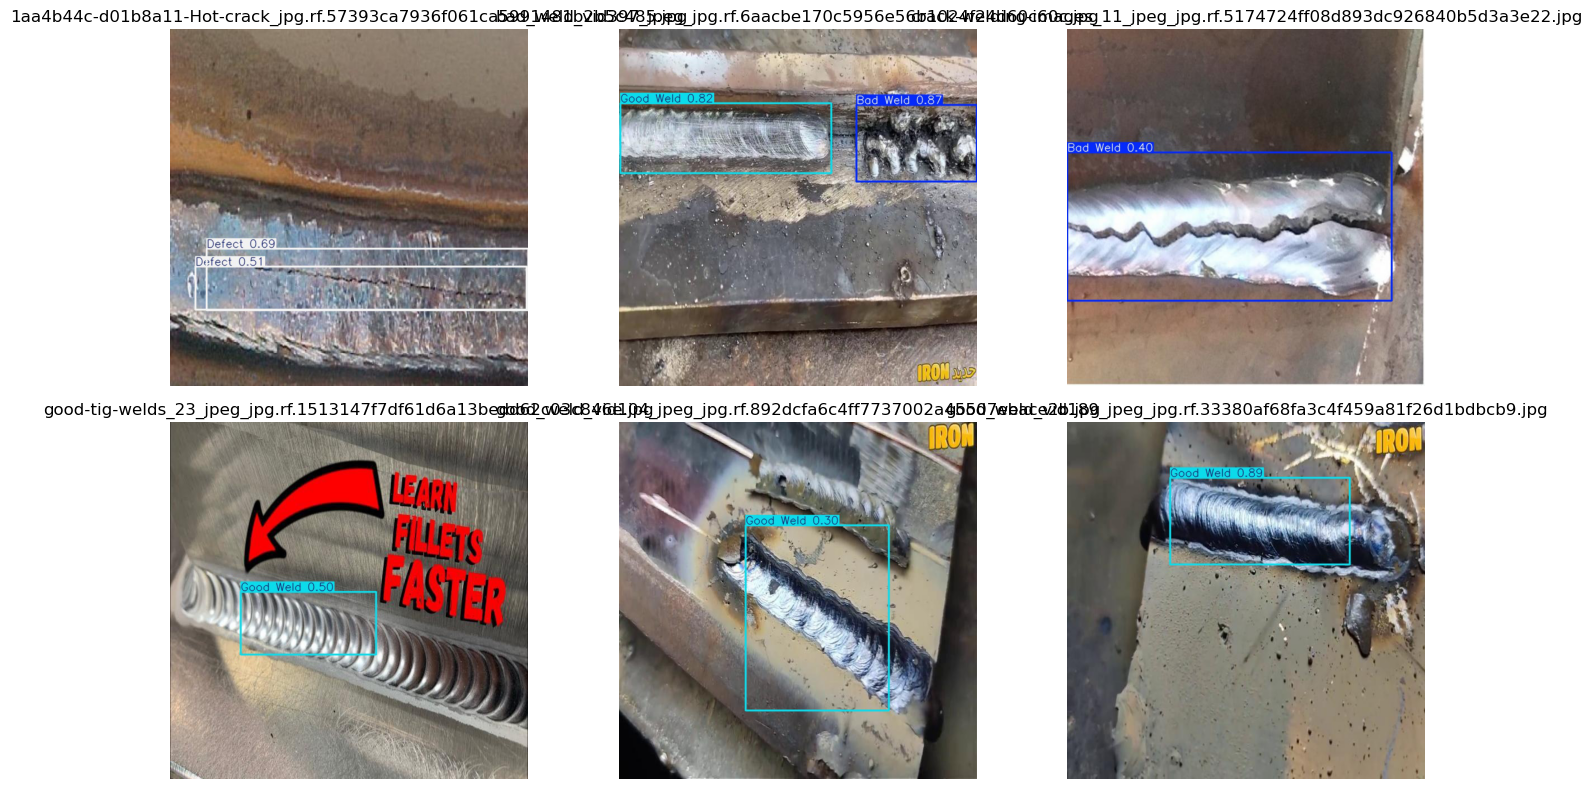

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

PRED_DIR = Path("pred_samples/yolov8s_test_preds")  # adjust if needed
imgs = list(PRED_DIR.glob("*.jpg")) + list(PRED_DIR.glob("*.png"))
print("Predicted images found:", len(imgs))

# show 6 predictions
plt.figure(figsize=(14, 8))
for i, p in enumerate(imgs[:6], 1):
    img = mpimg.imread(p)
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(p.name)
plt.tight_layout()
plt.show()


### Good detections: 
clear bounding boxes for Bad Weld/Good Weld when weld region is clean.

### Failure cases: 
Defect class sometimes missed due to small size, low contrast, or similarity to normal weld texture.

##  Metrics table

In [8]:
import pandas as pd

df = pd.DataFrame({
    "Model": ["YOLOv8n", "YOLOv8s"],
    "Parameters (M)": [3.0, 11.1],
    "Precision": [0.609, 0.631],
    "Recall": [0.511, 0.553],
    "mAP@0.5": [0.567, 0.591],
    "mAP@0.5:0.95": [0.317, 0.333]
})

df


,Model,Parameters (M),Precision,Recall,mAP@0.5,mAP@0.5:0.95
0,YOLOv8n,3.0,0.609,0.511,0.567,0.317
1,YOLOv8s,11.1,0.631,0.553,0.591,0.333


## analysis
- YOLOv8s generally achieves higher mAP than YOLOv8n because it has a larger backbone.
- The 'Defect' class is hardest due to small size/low contrast, leading to lower mAP.
- Augmentations (scale/translate/color jitter) help generalization; higher resolution may help small defects but slows FPS.
